In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ks_2samp

In [92]:
df = pd.read_csv('../data/creditcard_2023.csv')
df.drop(columns=['id'], inplace=True)
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,0.637735,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,0.529808,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,0.690708,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,0.575231,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,0.968046,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [106]:
split_60 = int(len(df) * 0.60)
df1 = df.iloc[:split_60].copy()  
df2  = df.iloc[split_60:].copy()  

print(f"\nTrain (60%) : {df1.shape}")
print(f"Test  (40%) : {df2.shape}")


Train (60%) : (341178, 30)
Test  (40%) : (227452, 30)


### Drift : Répartition des classes

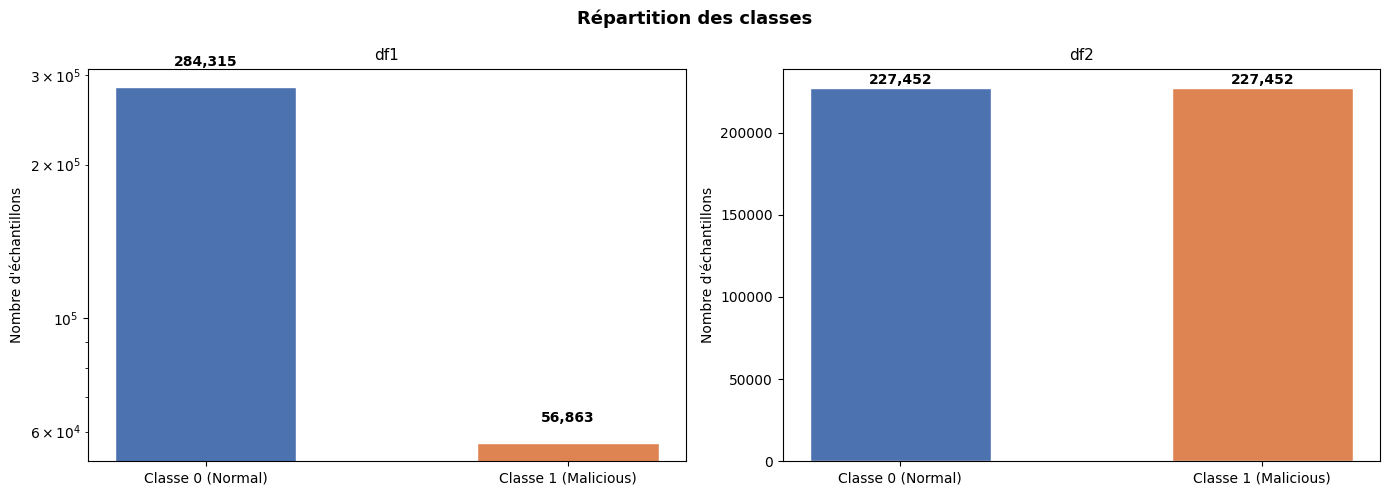

In [107]:
labels = ['Classe 0 (Normal)', 'Classe 1 (Malicious)']

df1_counts = df1["Class"].value_counts()
df2_counts = df2["Class"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Répartition des classes', fontsize=13, fontweight='bold')

colors = ['#4C72B0', '#DD8452']
x = np.arange(len(labels))
width = 0.5

bars1 = axes[0].bar(x, df1_counts, width=width, color=colors, edgecolor='white')
axes[0].set_title('df1', fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("Nombre d'échantillons")
axes[0].set_yscale('log')  
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.1,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(x, df2_counts, width=width, color=colors, edgecolor='white')
axes[1].set_title('df2', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Nombre d'échantillons")
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'{int(bar.get_height()):,}', ha='center', fontsize=10, fontweight='bold')


plt.tight_layout()
plt.show()

### Drift par feature

In [108]:
stats = []
for col in df1.columns:
    stat, p = ks_2samp(df1[col], df2[col])
    stats.append(stat)
    print(f"{col}: stat={stat:.3f}, p={p:.4f}")

V1: stat=0.390, p=0.0000
V2: stat=0.528, p=0.0000
V3: stat=0.582, p=0.0000
V4: stat=0.653, p=0.0000
V5: stat=0.360, p=0.0000
V6: stat=0.381, p=0.0000
V7: stat=0.545, p=0.0000
V8: stat=0.293, p=0.0000
V9: stat=0.485, p=0.0000
V10: stat=0.688, p=0.0000
V11: stat=0.640, p=0.0000
V12: stat=0.658, p=0.0000
V13: stat=0.058, p=0.0000
V14: stat=0.720, p=0.0000
V15: stat=0.035, p=0.0000
V16: stat=0.585, p=0.0000
V17: stat=0.638, p=0.0000
V18: stat=0.427, p=0.0000
V19: stat=0.280, p=0.0000
V20: stat=0.304, p=0.0000
V21: stat=0.440, p=0.0000
V22: stat=0.034, p=0.0000
V23: stat=0.107, p=0.0000
V24: stat=0.134, p=0.0000
V25: stat=0.053, p=0.0000
V26: stat=0.095, p=0.0000
V27: stat=0.397, p=0.0000
V28: stat=0.304, p=0.0000
Amount: stat=0.003, p=0.2348
Class: stat=0.833, p=0.0000


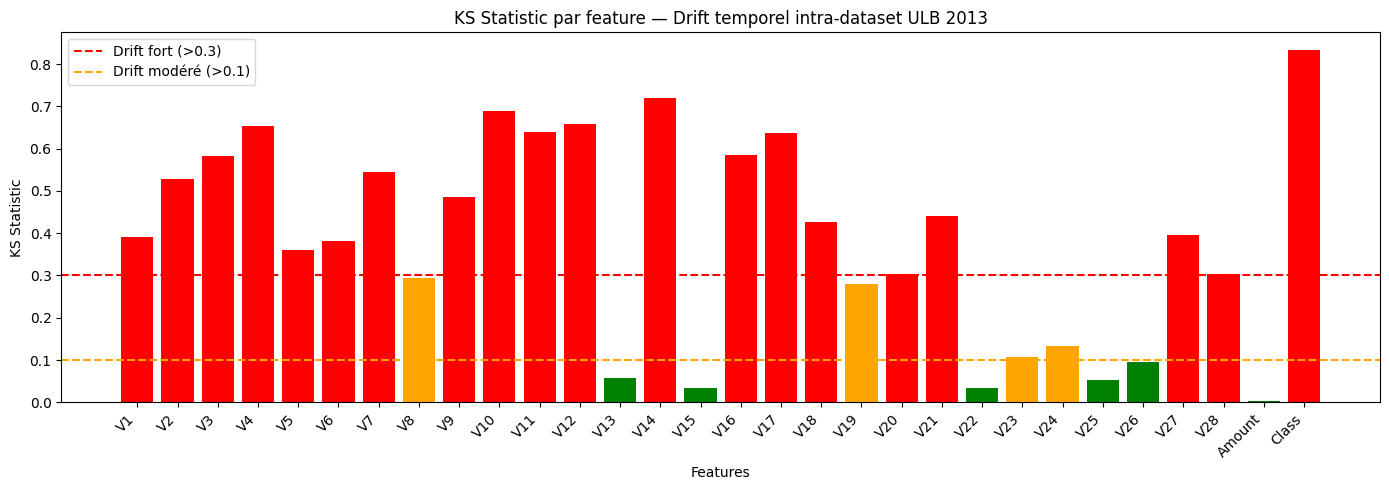

In [109]:
features = list(df1.columns)
stats_array = np.array(stats)  

colors = ['red' if s > 0.3 else 'orange' if s > 0.1 else 'green'
          for s in stats_array]

plt.figure(figsize=(14, 5))
plt.bar(features, stats_array, color=colors) 
plt.axhline(0.3, color='red', linestyle='--', label='Drift fort (>0.3)')
plt.axhline(0.1, color='orange', linestyle='--', label='Drift modéré (>0.1)')
plt.title('KS Statistic par feature — Drift temporel intra-dataset ULB 2013')
plt.ylabel('KS Statistic')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('ks_drift.png', dpi=150)
plt.show()